## ------------------------------------------
## TELCO CUSTOMER CHURN -> MODEL BUILDING
## Goal: Train Logistic Regression and XGBoost,
## compare class_weight vs SMOTE, evaluate using
## AUC-ROC and Recall
## ------------------------------------------

### Basic Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Loading Preprocess Data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 21)
X_test shape: (1407, 21)
y_train shape: (5625,)
y_test shape: (1407,)


### Baseline Model: Logistic Regression (class_weight='balanced')

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, classification_report) 

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Predictions

In [6]:
y_pred_lr = log_reg.predict(X_test)

# Probability that customer will churn
y_pred_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Metrics# Metrics
print("LOGISTIC REGRESSION (class_weight='balanced')")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION (class_weight='balanced')
Accuracy:  0.7292
Precision: 0.4941
Recall:    0.7888
F1 Score:  0.6076
AUC-ROC:   0.8331

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



### Confusion Matrix Visualization

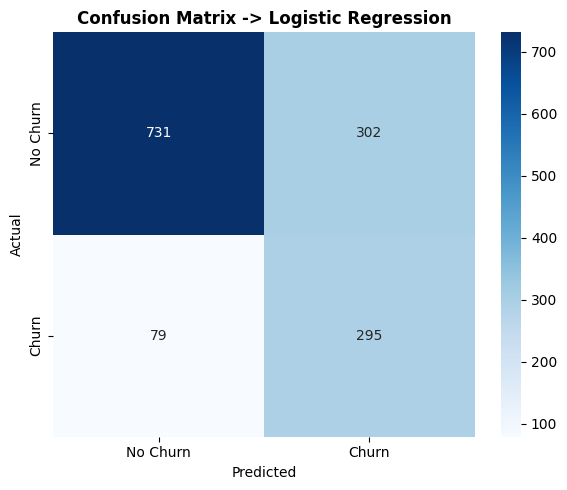

True Negatives:  731 (correctly predicted no churn)
False Positives: 302 (predicted churn, actually stayed)
False Negatives: 79 (predicted stayed, actually churned -> MISSED)
True Positives:  295 (correctly predicted churn)


In [7]:
# Visualize True Positives, False Positives,
# True Negatives, False Negatives

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix -> Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"True Negatives:  {cm_lr[0][0]} (correctly predicted no churn)")
print(f"False Positives: {cm_lr[0][1]} (predicted churn, actually stayed)")
print(f"False Negatives: {cm_lr[1][0]} (predicted stayed, actually churned -> MISSED)")
print(f"True Positives:  {cm_lr[1][1]} (correctly predicted churn)")